<a href="https://colab.research.google.com/github/dimasbayucmiiw/Kecerdasan-Buatan-2026/blob/main/Proyek_Analisis_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Dimas Bayu Pratama
- **NIM:** 4.33.25.0.07
- **Kelas:** TI - 1A

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana perbandingan jumlah rata-rata penyewaan sepeda antara hari kerja (working day) dan akhir pekan/hari libur?
- Pertanyaan 2: Bagaimana perbedaan pola jam penyewaan sepeda (waktu puncak) antara hari kerja dibandingkan dengan akhir pekan/hari libur?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [11]:
# Memuat data harian
day_df = pd.read_csv("/content/sample_data/day.csv")
print("Tampilan 5 baris pertama day_df:")
display(day_df.head())

# Memuat data per jam
hour_df = pd.read_csv("/content/sample_data/hour.csv")
print("\nTampilan 5 baris pertama hour_df:")
display(hour_df.head())

Tampilan 5 baris pertama day_df:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Tampilan 5 baris pertama hour_df:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

In [12]:
# Memeriksa struktur dan tipe data
print("Info dataset day.csv:")
day_df.info()
print("\nJumlah duplikasi pada day.csv: ", day_df.duplicated().sum())
print("\nMissing values pada day.csv:\n", day_df.isna().sum())

print("\n-----------------------------------\n")

print("Info dataset hour.csv:")
hour_df.info()
print("\nJumlah duplikasi pada hour.csv: ", hour_df.duplicated().sum())
print("\nMissing values pada hour.csv:\n", hour_df.isna().sum())

Info dataset day.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Jumlah duplikasi pada day.csv:  0

Missing values pada day.csv:
 insta

### Cleaning Data

In [10]:
# Mengubah tipe data kolom 'dteday' dari object menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Memetakan nilai kolom 'workingday' menjadi teks (0: Libur/Akhir Pekan, 1: Hari Kerja)
workingday_mapping = {0: 'Akhir Pekan / Libur', 1: 'Hari Kerja'}
day_df['workingday'] = day_df['workingday'].map(workingday_mapping)
hour_df['workingday'] = hour_df['workingday'].map(workingday_mapping)

## Exploratory Data Analysis (EDA)

### Explore ...

In [13]:
# Menghitung rata-rata penyewaan harian berdasarkan jenis hari (Hari Kerja vs Libur)
rata_rata_hari = day_df.groupby('workingday')['cnt'].mean().reset_index()
print("Rata-rata penyewaan berdasarkan jenis hari:")
display(rata_rata_hari)

# Menghitung rata-rata penyewaan per jam, dibedakan berdasarkan jenis hari
rata_rata_jam_hari = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()
print("\nRata-rata penyewaan per jam (Hari Kerja vs Libur):")
display(rata_rata_jam_hari.head(10)) # Menampilkan 10 baris pertama saja sebagai contoh

Rata-rata penyewaan berdasarkan jenis hari:


,workingday,cnt
0,0,4330.168831
1,1,4584.820000



Rata-rata penyewaan per jam (Hari Kerja vs Libur):


,workingday,hr,cnt
0,0,0,90.800000
1,0,1,69.508696
2,0,2,53.171053
3,0,3,25.775330
4,0,4,8.264317
5,0,5,8.689189
6,0,6,18.742358
7,0,7,43.406926
8,0,8,105.653680
9,0,9,171.623377


## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_1611/1082875533.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


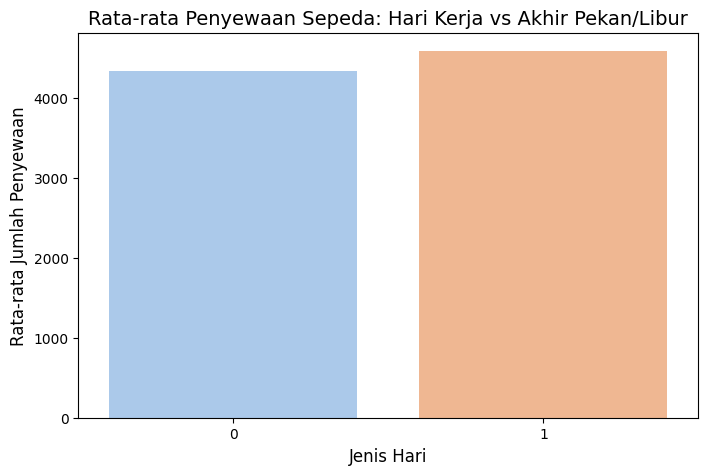

In [14]:
# Visualisasi perbandingan penyewaan: Hari Kerja vs Akhir Pekan/Libur
plt.figure(figsize=(8, 5))
sns.barplot(
    x='workingday',
    y='cnt',
    data=rata_rata_hari,
    palette='pastel'
)
plt.title('Rata-rata Penyewaan Sepeda: Hari Kerja vs Akhir Pekan/Libur', fontsize=14)
plt.xlabel('Jenis Hari', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.show()

### Pertanyaan 2:

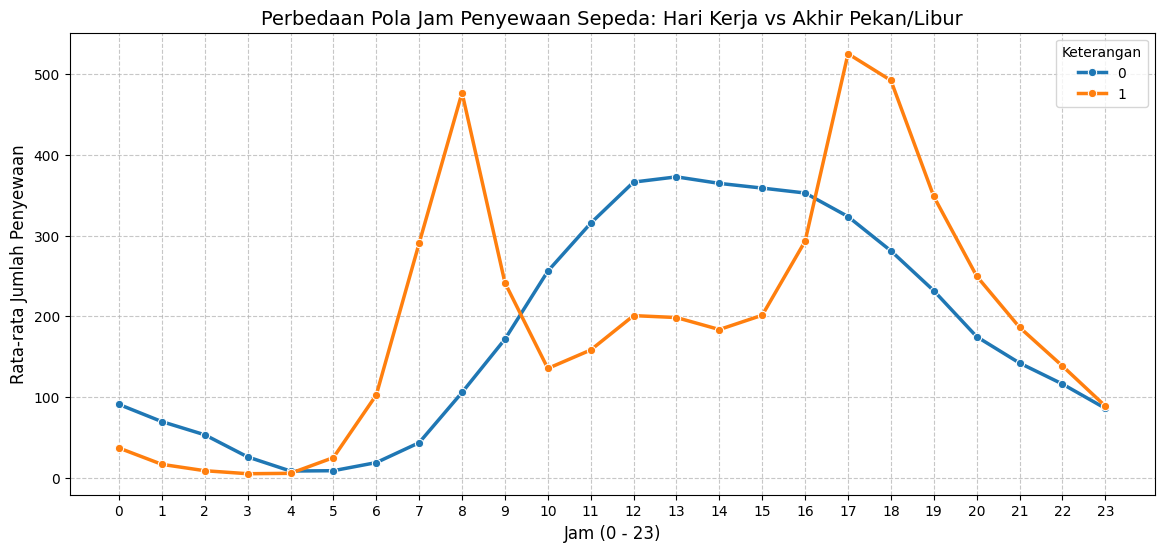

In [15]:
# Visualisasi tren penyewaan per jam (dibedakan berdasarkan workingday)
plt.figure(figsize=(14, 6))
sns.lineplot(
    x='hr',
    y='cnt',
    hue='workingday', # Membedakan garis berdasarkan jenis hari
    data=rata_rata_jam_hari,
    marker='o',
    linewidth=2.5
)
plt.title('Perbedaan Pola Jam Penyewaan Sepeda: Hari Kerja vs Akhir Pekan/Libur', fontsize=14)
plt.xlabel('Jam (0 - 23)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Keterangan')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Conclusion

- **Conclusion pertanyaan 1:** Jumlah rata-rata penyewaan sepeda cenderung sedikit lebih tinggi pada hari kerja dibandingkan dengan akhir pekan atau hari libur. Ini menunjukkan bahwa layanan penyewaan sepeda lebih dominan digunakan untuk rutinitas harian dibandingkan sekadar rekreasi.
- **Conclusion pertanyaan 2:** Terdapat perbedaan pola yang sangat mencolok pada jam penyewaan. Pada **Hari Kerja**, terjadi dua lonjakan drastis (puncak) pada pukul 08:00 dan 17:00, yang bertepatan dengan jam berangkat dan pulang kerja/sekolah. Sebaliknya, pada **Akhir Pekan/Libur**, polanya berbentuk kurva mulus yang memuncak di siang hingga sore hari (sekitar pukul 12:00 - 16:00), mengindikasikan penggunaan sepeda untuk bersantai atau rekreasi di waktu luang.